# Notebook 2: Data Preprocessing for Sentiment Analysis

## Purpose
Clean and prepare KFC Trustpilot reviews for sentiment classification.

## Key Difference from Reddit Version
- Input column is `Review Text` (not `Comment`)
- Trustpilot reviews tend to be longer and more structured than Reddit comments
- Stopwords adapted for Trustpilot review language

## Input
`kfc_trustpilot_reviews_2025_2026.csv` (from Notebook 1)

## Output
- `kfc_tp_preprocessed_sentiment.csv`
- `wordcloud_all_reviews.png`

## Step 0 - Import Libraries

In [1]:
!pip install --upgrade setuptools pip --user

In [2]:
!pip install pandas wordcloud matplotlib
!pip3 install nltk

import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
print("Libraries loaded.")

Libraries loaded.


## Step 1 - Configuration

In [3]:
INPUT_FILE  = "kfc_trustpilot_reviews_2025_2026.csv"
OUTPUT_FILE = "kfc_tp_preprocessed_sentiment.csv"
WORDCLOUD_FILE = "wordcloud_all_reviews.png"

## Step 2 - Custom Stopwords

Adapted for Trustpilot review language (more formal than Reddit).

In [4]:
CUSTOM_STOPWORDS = set(stopwords.words("english")).union({
    # Brand-specific
    "kfc", "kentucky", "fried", "chicken",
    # Contractions / informal
    "s", "t", "m", "don", "wa", "ha", "im", "ive", "cant", "dont",
    "doesnt", "didnt", "thats", "theyre", "u", "ur", "lol", "yeah", "ok", "okay",
    # Common verbs
    "go", "got", "get", "make", "going", "will", "would", "used",
    "use", "want", "know", "think", "work", "see", "need",
    # Time-related
    "time", "day", "year", "now", "today", "always", "ago", "last",
    # Pronouns
    "they", "them", "you", "me", "my", "their", "i", "we", "he", "she",
    # Quantity / Intensity
    "much", "still", "even", "really", "actually", "every", "everything",
    # General / Neutral
    "thing", "one", "new", "something", "back", "also", "like", "just",
    # Sentiment words too generic
    "good", "better", "bad", "pretty", "nice",
    # Order-related
    "order", "ordered",
    # Trustpilot-specific neutral terms
    "review", "experience", "visit", "visited", "store", "branch",
    # Miscellaneous
    "well", "people", "place", "said", "say", "way", "went",
})

print(f"Custom stopwords: {len(CUSTOM_STOPWORDS)} words")

Custom stopwords: 273 words


## Step 3 - Load Dataset

In [5]:
df = pd.read_csv(INPUT_FILE)
print(f"Rows loaded: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Rows loaded: 200
Columns: ['Review Title', 'Review Text', 'Star Rating', 'Date', 'Author']


,Review Title,Review Text,Star Rating,Date,Author
0,easy way to order cold food from KFC,Ordered a meal from KFC Haslingden rd Blackbur...,1,2026-03-27,Paul Buckland
1,Rip off for delivery,"For a place that has quite high prices, it's d...",1,2025-12-03,Jason Lewis
2,Great customer service from Emmanuel in…,Great customer service from Emmanuel in the ar...,5,2026-03-27,Ceri Smith
3,Why eat chicken there when I found out not nat...,Why eat chicken there when I found out it’s la...,1,2026-03-26,Jane .
4,KFC Macclesfield,"Items missing from order, no chance of getting...",1,2026-03-26,Simon Baker


## Step 4 - Remove Null / Blank Reviews

In [6]:
before = len(df)
df = df.dropna(subset=["Review Text"])
df = df[df["Review Text"].str.strip().astype(bool)]
after = len(df)
print(f"Removed {before - after} null/blank rows")
print(f"Remaining: {after} rows")

Removed 0 null/blank rows
Remaining: 200 rows


## Step 5 - Text Cleaning & Tokenisation

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_review(text):
    """Clean -> tokenise -> remove stopwords -> lemmatise."""
    lemmatizer = WordNetLemmatizer()
    cleaned = clean_text(text)
    tokens = cleaned.split()
    tokens = [t for t in tokens if t not in CUSTOM_STOPWORDS and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

print("Preprocessing all reviews...")
df["Tokenised_Review"] = df["Review Text"].apply(preprocess_review)

before = len(df)
df = df[df["Tokenised_Review"].str.strip().astype(bool)]
print(f"Removed {before - len(df)} empty rows")
print(f"Final rows: {len(df)}")

Preprocessing all reviews...
Removed 0 empty rows
Final rows: 200


## Step 6 - Word Cloud

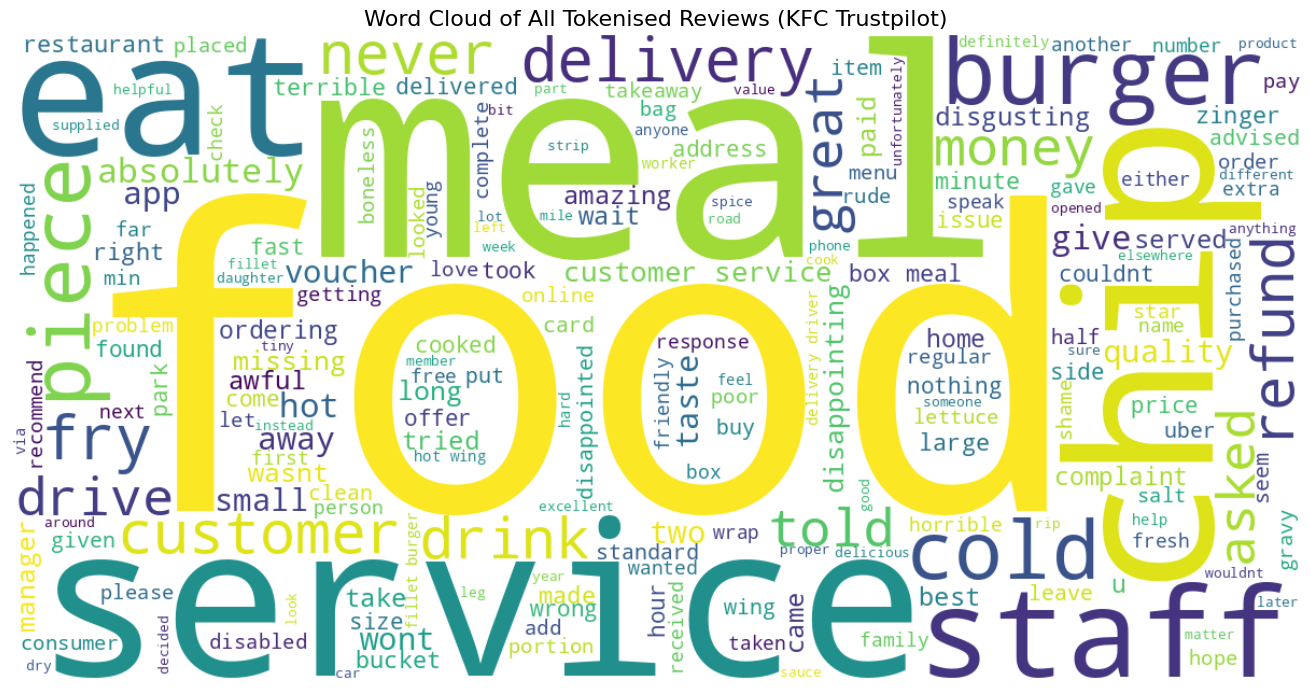

In [8]:
all_words = " ".join(df["Tokenised_Review"])
wc = WordCloud(width=1200, height=600, background_color="white",
               max_words=200, colormap="viridis").generate(all_words)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.title("Word Cloud of All Tokenised Reviews (KFC Trustpilot)", fontsize=16)
plt.axis("off"); plt.tight_layout()
plt.savefig(WORDCLOUD_FILE, dpi=150, bbox_inches="tight")
plt.show()

## Step 7 - Save Preprocessed Dataset

In [10]:
df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
print(f"Saved to: {OUTPUT_FILE}")
print(f"Total reviews: {len(df)}")

Saved to: kfc_tp_preprocessed_sentiment.csv
Total reviews: 200
